In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [7]:
# Cell 2 — Version 1: NeuralNetwork class
class NeuralNetwork:
    def __init__(self, layer_sizes, lr=0.01):
        """
        layer_sizes: list e.g. [2, 4, 1]
                     means input=2, hidden=4, output=1
        """
        self.lr     = lr
        self.weights = []
        self.biases  = []
        np.random.seed(42)
        for i in range(len(layer_sizes)-1):
            W = np.random.randn(layer_sizes[i],
                                layer_sizes[i+1]) * 0.1
            b = np.zeros(layer_sizes[i+1])
            self.weights.append(W)
            self.biases.append(b)

    def sigmoid(self, z):    return 1 / (1 + np.exp(-z))
    def sigmoid_d(self, z):  return self.sigmoid(z) * (1 - self.sigmoid(z))

    def forward(self, X):
        self.zs, self.as_ = [], [X]
        a = X
        for W, b in zip(self.weights, self.biases):
            z = a @ W + b
            a = self.sigmoid(z)
            self.zs.append(z)
            self.as_.append(a)
        return a

    def backward(self, y):
        m      = y.shape[0]
        delta  = 2*(self.as_[-1] - y)/m * self.sigmoid_d(self.zs[-1])
        for i in reversed(range(len(self.weights))):
            dW = self.as_[i].T @ delta
            db = delta.sum(axis=0)
            self.weights[i] -= self.lr * dW
            self.biases[i]  -= self.lr * db
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.sigmoid_d(self.zs[i-1])

    def fit(self, X, y, epochs=1000):
        losses = []
        for epoch in range(epochs):
            out  = self.forward(X)
            loss = np.mean((out - y)**2)
            losses.append(loss)
            self.backward(y)
            if epoch % 200 == 0:
                print(f"Epoch {epoch:5d} | Loss={loss:.6f}")
        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

print("NeuralNetwork class defined ✅")

NeuralNetwork class defined ✅


Epoch     0 | Loss=0.249712
Epoch   200 | Loss=0.249693
Epoch   400 | Loss=0.249673
Epoch   600 | Loss=0.249653
Epoch   800 | Loss=0.249632
Epoch  1000 | Loss=0.249609
Epoch  1200 | Loss=0.249585
Epoch  1400 | Loss=0.249559
Epoch  1600 | Loss=0.249530
Epoch  1800 | Loss=0.249497

Test Accuracy: 43.3%


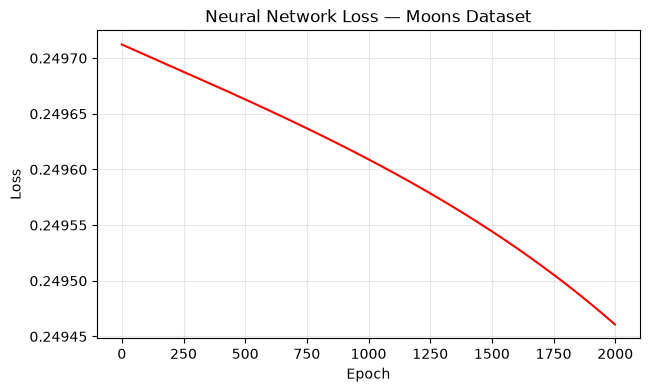

In [8]:
# Cell 3 — Version 2: train on moons dataset
np.random.seed(42)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X    = StandardScaler().fit_transform(X)
y    = y.reshape(-1, 1).astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

nn = NeuralNetwork(layer_sizes=[2, 8, 4, 1], lr=0.05)
losses = nn.fit(X_train, y_train, epochs=2000)

acc = accuracy_score(y_test, nn.predict(X_test))
print(f"\nTest Accuracy: {acc*100:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot(losses, 'r-', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Neural Network Loss — Moons Dataset')
plt.grid(True, alpha=0.3); plt.show()

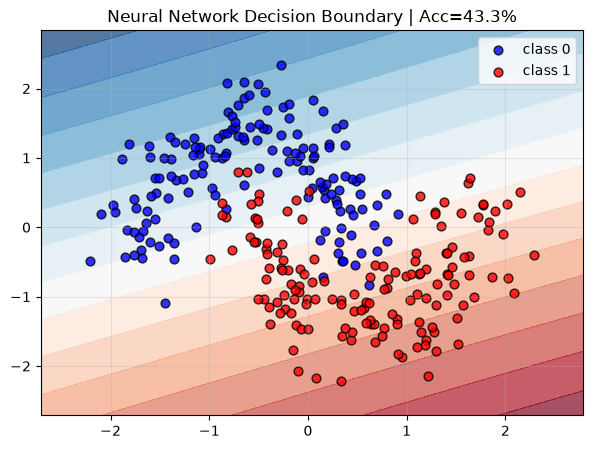

In [9]:
# Cell 4 — Version 3: decision boundary on moons
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z    = nn.forward(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            c='blue', s=40, edgecolors='k', alpha=0.8, label='class 0')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            c='red',  s=40, edgecolors='k', alpha=0.8, label='class 1')
plt.title(f'Neural Network Decision Boundary | Acc={acc*100:.1f}%')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

Final test accuracy: 52.5%


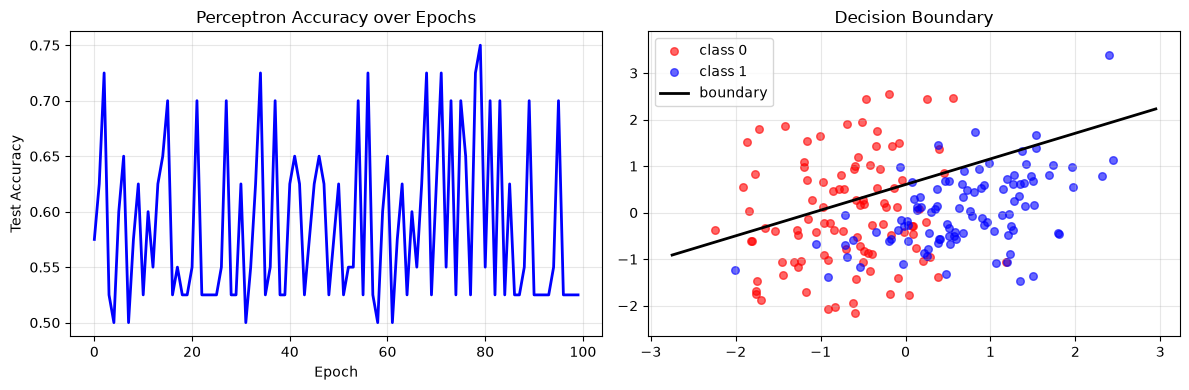

In [5]:
# Cell 5 — Version 4: perceptron on real data (binary classification)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42,
                            n_clusters_per_class=1)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

w = np.zeros(2); b = 0.0; lr = 0.01
accs = []

for epoch in range(100):
    for xi, yi in zip(X_train, y_train):
        y_pred = step(np.dot(w, xi) + b)
        error  = yi - y_pred
        w += lr * error * xi
        b += lr * error
    preds = np.array([step(np.dot(w, xi) + b) for xi in X_test])
    accs.append(np.mean(preds == y_test))

print(f"Final test accuracy: {accs[-1]*100:.1f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(accs, 'b-', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.title('Perceptron Accuracy over Epochs')
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
x1r = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300)
x2b = (-w[0]*x1r - b) / w[1]
plt.scatter(X[y==0,0], X[y==0,1], c='red',  s=30, alpha=0.6, label='class 0')
plt.scatter(X[y==1,0], X[y==1,1], c='blue', s=30, alpha=0.6, label='class 1')
plt.plot(x1r, x2b, 'k-', linewidth=2, label='boundary')
plt.ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)
plt.title('Decision Boundary'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()